Python notebook to calculate various statistics between two annotations.

## Data and Libraries

In [53]:
from dataset_processing import cwed4eta_process_json_file, convert_to_token_spans, CLIRENER_LABELS_V1, process_directory_of_json_files

import numpy as np
import krippendorff
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from os import listdir
from pathlib import Path
import itertools

from collections import defaultdict, Counter

from nltk.metrics.agreement import AnnotationTask
import json


### Helper Functions

In [54]:

def generate_consistent_label_map(entity_types):
    """
    Generates a consistent BIO label map from a set of raw entity types.
    Ensures 'O' is included and indices are deterministic (sorted).
    """
    # 1. Always start with 'O'
    bio_labels = ["O"]
    
    # 2. Create B- and I- tags for every entity type
    sorted_types = sorted(list(entity_types))
    for label in sorted_types:
        bio_labels.append(f"B-{label}")
        bio_labels.append(f"I-{label}")
        
    # 3. Create the dictionary: {'O': 0, 'B-Asset': 1, ...}
    # We sort the final list to ensure 'O' and the rest are in a predictable order
    # (Optional: You can enforce 'O' to be 0 specifically, but alphabetical sort is also fine)
    bio_labels.sort()
    
    return {label: i for i, label in enumerate(bio_labels)}

def spans_to_bio_tags(token_list, ner_spans):
    tags = ["O"] * len(token_list)
    if not ner_spans:
        return tags
    
    for i, item in enumerate(ner_spans):
        # 1. Unpack carefully
        if isinstance(item, dict):
            start = item['start']
            end = item['end']
            label = item['label']
        else:
            # List format [start, end, label, ...]
            start = item[0]
            end = item[1]
            label = item[2]

        # 2. Validation
        if start >= len(tags):
            print(f"⚠️ Ignored Span {i}: Start {start} > DocLen {len(tags)}")
            continue
            
        # 3. Apply Tags
        b_tag = f"B-{label}"
        i_tag = f"I-{label}"
        
        tags[start] = b_tag
        
        # Handle Inclusive vs Exclusive confusion
        # If your data is Inclusive (e.g. start=1, end=1 is one token)
        if end > start:
            # Range is exclusive at top, so +1
            limit = min(end + 1, len(tags)) 
            for j in range(start + 1, limit):
                tags[j] = i_tag
                
    return tags

def spans_to_bio_tags_legacy(token_list, ner_spans):
    
    tags = ["O"] * len(token_list)
    if len(ner_spans[0]) == 3:
        for start, end, label in ner_spans:
            # Construct the expected tags
            b_tag = f"B-{label}"
            i_tag = f"I-{label}"
            
            # Apply B tag
            tags[start] = b_tag
            
            # Apply I tags
            if end > start:
                for i in range(start + 1, end + 1):
                    tags[i] = i_tag
    elif len(ner_spans[0]) == 4:
        for start, end, label, _ in ner_spans:
            # Construct the expected tags
            b_tag = f"B-{label}"
            i_tag = f"I-{label}"
            
            # Apply B tag
            tags[start] = b_tag
            
            # Apply I tags
            if end > start:
                for i in range(start + 1, end + 1):
                    tags[i] = i_tag
    return tags

def calculate_ner_agreement(data_coder_1, data_coder_2, label_map=None):
    """
    Calculates Alpha and Confusion Matrix using a consistent label map.
    
    Args:
        data_coder_1: List of dicts from Coder 1
        data_coder_2: List of dicts from Coder 2
        label_map: (Optional) Precomputed dict {'B-Person': 1, ...}. 
                   If None, generates it from CLIRENER_LABELS_V1.
    """
    
    # If no map provided, generate the default one
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    # Dictionary lookup for faster access by ID
    dict_c1 = {d['id']: d for d in data_coder_1}
    dict_c2 = {d['id']: d for d in data_coder_2}
    
    common_ids = set(dict_c1.keys()).intersection(set(dict_c2.keys()))
    
    if not common_ids:
        print("No matching IDs found between datasets.")
        return None, 0, None, label_map

    all_tags_1 = []
    all_tags_2 = []

    # Iterate through matched documents
    for doc_id in sorted(common_ids):
        doc1 = dict_c1[doc_id]
        doc2 = dict_c2[doc_id]
        
        # Sanity check: Token length
        tokens = doc1['tokenized_text']
        if len(tokens) != len(doc2['tokenized_text']):
            print(f"Warning: Token mismatch for ID {doc_id}. Skipping.")
            continue
            
        # Convert spans to BIO tags
        tags1 = spans_to_bio_tags(tokens, doc1['ner'])
        tags2 = spans_to_bio_tags(tokens, doc2['ner'])
        
        all_tags_1.extend(tags1)
        all_tags_2.extend(tags2)

    # --- Encode Tags to Integers ---
    encoded_row_1 = []
    encoded_row_2 = []
    
    try:
        encoded_row_1 = [label_map[t] for t in all_tags_1]
        encoded_row_2 = [label_map[t] for t in all_tags_2]
    except KeyError as e:
        print(f"CRITICAL ERROR: Found a tag in data that is not in CLIRENER_LABELS_V1: {e}")
        print("Please update your constant set or fix the data.")
        return None, 0, None, label_map

    # --- Calculate Krippendorff's Alpha ---
    reliability_data = [encoded_row_1, encoded_row_2]
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement="nominal"
    )

    # --- Calculate Confusion Matrix ---
    # IMPORTANT: We pass the full list of label_map values (0 to N) to 'labels'.
    # This ensures the matrix is always the full size (e.g. 57x57) even if 
    # some tags (like B-Body Part) don't appear in this specific dataset.
    all_possible_indices = sorted(list(label_map.values()))
    
    cm = confusion_matrix(
        encoded_row_1, 
        encoded_row_2, 
        labels=all_possible_indices
    )
    
    return alpha, len(all_tags_1), cm, label_map


def print_top_confusions(conf_mat, label_map, top_n=10):
    index_to_label = {v: k for k, v in label_map.items()}
    confusions = []

    rows, cols = conf_mat.shape
    for r in range(rows):
        for c in range(cols):
            if r != c: # Skip correct matches
                count = conf_mat[r, c]
                if count > 0:
                    confusions.append((count, index_to_label[r], index_to_label[c]))

    # Sort by count descending
    confusions.sort(key=lambda x: x[0], reverse=True)

    print(f"{'Count':<10} | {'Coder 1 (Row)':<30} -> {'Coder 2 (Col)':<30}")
    print("-" * 75)
    for count, l1, l2 in confusions[:top_n]:
        print(f"{count:<10} | {l1:<30} -> {l2:<30}")


def plot_ner_confusion_matrix(conf_mat, label_map, hide_diagonal=True):
    """
    Plots a large confusion matrix for NER.
    
    Args:
        conf_mat: The square matrix (numpy array) returned by confusion_matrix()
        label_map: The dictionary {'Label': index} used for encoding
        hide_diagonal: If True, sets diagonal to 0 to highlight ERRORS only.
    """
    
    # 1. Get labels in the correct sorted order (0, 1, 2...)
    # We invert the dictionary: {0: 'B-Asset', 1: 'B-Body...', ...}
    index_to_label = {v: k for k, v in label_map.items()}
    labels = [index_to_label[i] for i in range(len(index_to_label))]

    # 2. Prepare data for plotting
    plot_data = conf_mat.copy()
    
    # (Optional) Zero out the diagonal to make the ERRORS pop out.
    # Otherwise, the massive agreement on 'O' tag washes out the colors.
    if hide_diagonal:
        np.fill_diagonal(plot_data, 0)

    # 3. Create the Plot
    # Size must be large (e.g., 24x24) to accommodate 55+ labels
    plt.figure(figsize=(24, 24))
    
    sns.heatmap(
        plot_data, 
        annot=True,           # Show numbers in cells
        fmt="d",              # Format as integer (d)
        cmap="Reds",          # Color scheme (Darker red = more confusion)
        xticklabels=labels, 
        yticklabels=labels,
        cbar_kws={'label': 'Count of Disagreements'}
    )

    plt.title("NER Confusion Matrix (Coder 1 vs Coder 2)", fontsize=20)
    plt.ylabel("Coder 1 (True/Reference)", fontsize=15)
    plt.xlabel("Coder 2 (Predicted)", fontsize=15)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    plt.tight_layout()
    plt.show()


def calculate_ner_agreement_generalized(list_of_coder_data, label_map=None):
    """
    Calculates Alpha and Aggregated Confusion Matrix for N annotators.
    
    Args:
        list_of_coder_data: A list containing datasets for each coder. 
                            Example: [data_coder_1, data_coder_2, data_coder_3]
        label_map: (Optional) Precomputed dict. If None, generates from CLIRENER_LABELS_V1.
    """
    
    num_coders = len(list_of_coder_data)
    if num_coders < 2:
        print("Error: Need at least 2 coders to calculate agreement.")
        return None, 0, None, label_map

    # 1. Generate Label Map if missing
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    # 2. Index all datasets by ID for fast lookup
    # coder_dicts is a list of dictionaries: [{id: doc}, {id: doc}, ...]
    coder_dicts = [{d['id']: d for d in dataset} for dataset in list_of_coder_data]

    # 3. Find intersection of IDs across ALL coders
    # Start with IDs from the first coder
    common_ids = set(coder_dicts[0].keys())
    # Intersect with every other coder
    for c_dict in coder_dicts[1:]:
        common_ids.intersection_update(c_dict.keys())
    
    if not common_ids:
        print("No common document IDs found across all provided datasets.")
        return None, 0, None, label_map

    print(f"Calculating agreement on {len(common_ids)} common documents among {num_coders} coders.")

    # 4. Prepare data containers (List of lists)
    # encoded_rows[0] will hold all integer tags for Coder 1, etc.
    encoded_rows = [[] for _ in range(num_coders)]
    total_tokens = 0

    # 5. Iterate through matched documents
    for doc_id in sorted(common_ids):
        
        # A. Sanity Check: Token lengths must match across ALL coders
        token_counts = [len(c_dict[doc_id]['tokenized_text']) for c_dict in coder_dicts]
        if len(set(token_counts)) != 1:
            print(f"Warning: Token length mismatch for ID {doc_id} among coders {token_counts}. Skipping.")
            continue
        
        # Use tokens from the first coder (since we verified they are all same length)
        tokens = coder_dicts[0][doc_id]['tokenized_text']
        total_tokens += len(tokens)

        # B. Convert spans to BIO tags for each coder
        for i in range(num_coders):
            doc_data = coder_dicts[i][doc_id]
            
            try:
                tags = spans_to_bio_tags(tokens, doc_data['ner'])
                encoded = [label_map[t] for t in tags]
                encoded_rows[i].extend(encoded)
            except KeyError as e:
                print(f"CRITICAL ERROR: Tag not in map: {e}")
                return None, 0, None, label_map

    # --- 6. Calculate Krippendorff's Alpha ---
    # input must be shape (n_coders, n_items)
    alpha = krippendorff.alpha(
        reliability_data=encoded_rows,
        level_of_measurement="nominal"
    )

    # --- 7. Calculate Aggregated Confusion Matrix ---
    # We sum the confusion matrices of all unique pairs.
    all_possible_indices = sorted(list(label_map.values()))
    num_classes = len(all_possible_indices)
    
    # Initialize an empty square matrix
    aggregated_cm = np.zeros((num_classes, num_classes), dtype=int)
    
    # Generate all unique pairs of coders (e.g., (0,1), (0,2), (1,2))
    pairs = list(itertools.combinations(range(num_coders), 2))
    
    for coder_a_idx, coder_b_idx in pairs:
        pair_cm = confusion_matrix(
            encoded_rows[coder_a_idx], 
            encoded_rows[coder_b_idx], 
            labels=all_possible_indices
        )
        aggregated_cm += pair_cm

    return alpha, total_tokens, aggregated_cm, label_map

# 
def calculate_ner_agreement_partial(list_of_coder_data, min_overlap=2, label_map=None):
    """
    Calculates Alpha and Aggregated Confusion Matrix for documents annotated by 
    AT LEAST `min_overlap` coders. Handles missing data using np.nan.
    
    Args:
        list_of_coder_data: List of lists (datasets).
        min_overlap: Minimum number of annotators required per document to include it.
        label_map: (Optional) Label dictionary.
    """
    
    num_coders = len(list_of_coder_data)
    if num_coders < min_overlap:
        print(f"Error: Not enough coders provided ({num_coders}) to satisfy min_overlap ({min_overlap}).")
        return None, 0, None, label_map

    # 1. Generate Label Map
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    # 2. Index datasets
    coder_dicts = [{d['id']: d for d in dataset} for dataset in list_of_coder_data]

    # 3. Find Union of all IDs
    all_ids = set()
    for c_dict in coder_dicts:
        all_ids.update(c_dict.keys())
        
    # 4. Filter IDs by "At Least N" overlap
    valid_ids = []
    for doc_id in all_ids:
        # Count how many coders have this doc_id
        count = sum(1 for c_dict in coder_dicts if doc_id in c_dict)
        if count >= min_overlap:
            valid_ids.append(doc_id)
            
    if not valid_ids:
        print(f"No documents found with at least {min_overlap} annotators.")
        return None, 0, None, label_map
    
    # Sort for deterministic processing order
    valid_ids.sort()
    
    print(f"Processing {len(valid_ids)} documents (filtered for >={min_overlap} overlap).")

    # 5. Build Reliability Matrix (Rows=Coders, Cols=Tokens) with np.nan
    # We build lists first, then convert to numpy array
    encoded_rows = [[] for _ in range(num_coders)]
    total_tokens_processed = 0

    for doc_id in valid_ids:
        # A. Find a "Reference" coder (anyone who annotated this doc) to get token length
        # We know at least `min_overlap` coders have it.
        reference_coder_idx = next(i for i, d in enumerate(coder_dicts) if doc_id in d)
        tokens = coder_dicts[reference_coder_idx][doc_id]['tokenized_text']
        doc_len = len(tokens)
        total_tokens_processed += doc_len

        # B. Process each coder
        for i in range(num_coders):
            c_dict = coder_dicts[i]
            
            if doc_id in c_dict:
                # Validate token length matches reference
                current_tokens = c_dict[doc_id]['tokenized_text']
                if len(current_tokens) != doc_len:
                    print(f"Warning: Token mismatch ID {doc_id} (Coder {i}). Padding with NaN.")
                    encoded_rows[i].extend([np.nan] * doc_len)
                    continue

                try:
                    # Convert spans to BIO tags -> Integers
                    tags = spans_to_bio_tags(current_tokens, c_dict[doc_id]['ner'])
                    encoded_vals = [label_map[t] for t in tags]
                    encoded_rows[i].extend(encoded_vals)
                except KeyError as e:
                    print(f"CRITICAL ERROR: Tag not in map: {e}")
                    return None, 0, None, label_map
            else:
                # This coder did NOT annotate this document -> Pad with NaNs
                encoded_rows[i].extend([np.nan] * doc_len)

    # Convert to numpy array for Krippendorff
    reliability_data = np.array(encoded_rows)

    # --- 6. Calculate Krippendorff's Alpha ---
    # Krippendorff handles np.nan automatically
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement="nominal"
    )

    # --- 7. Calculate Aggregated Confusion Matrix ---
    # We must explicitly handle NaNs here (only compare where BOTH exist)
    all_possible_indices = sorted(list(label_map.values()))
    num_classes = len(all_possible_indices)
    aggregated_cm = np.zeros((num_classes, num_classes), dtype=int)
    
    pairs = list(itertools.combinations(range(num_coders), 2))
    
    for c1_idx, c2_idx in pairs:
        row_1 = reliability_data[c1_idx]
        row_2 = reliability_data[c2_idx]
        
        # Create a mask where BOTH are NOT NaN
        # (i.e., tokens where both Coder A and Coder B provided an annotation)
        valid_mask = (~np.isnan(row_1)) & (~np.isnan(row_2))
        
        if np.any(valid_mask):
            # Extract valid comparisons and convert to int
            y_true = row_1[valid_mask].astype(int)
            y_pred = row_2[valid_mask].astype(int)
            
            pair_cm = confusion_matrix(
                y_true, 
                y_pred, 
                labels=all_possible_indices
            )
            aggregated_cm += pair_cm

    return alpha, total_tokens_processed, aggregated_cm, label_map


def flag_overlapping_token_spans(tokenized_data):
    """
    Scans tokenized documents for overlapping token-level NER spans 
    and prints them out for manual review.
    """
    total_docs_with_overlaps = 0
    
    for doc in tokenized_data:
        doc_id = doc.get('id', 'Unknown ID')
        ner_spans = doc.get('ner', [])
        tokens = doc.get('tokenized_text',[])
        
        doc_overlaps =[]
        n = len(ner_spans)
        
        # Compare every pair of entity spans in the sentence
        for i in range(n):
            for j in range(i + 1, n):
                span1 = ner_spans[i]
                span2 = ner_spans[j]
                
                start1, end1, label1 = span1[0], span1[1], span1[2]
                start2, end2, label2 = span2[0], span2[1], span2[2]
                
                # Check for overlap. Because your token ends are INCLUSIVE,
                # we use <= instead of strictly <
                if max(start1, start2) <= min(end1, end2):
                    doc_overlaps.append((span1, span2))
        
        # Print results if any overlaps were found in this document
        if doc_overlaps:
            total_docs_with_overlaps += 1
            print(f"\n🚨 Overlap found in Document ID: {doc_id}")
            
            for s1, s2 in doc_overlaps:
                # Reconstruct the text for readability (slice is end+1 because lists are exclusive)
                text1 = " ".join(tokens[s1[0] : s1[1] + 1])
                text2 = " ".join(tokens[s2[0] : s2[1] + 1])
                
                print(f"   ➔ '{text1}' ({s1[2]} tokens[{s1[0]}:{s1[1]}])")
                print(f"      OVERLAPS WITH")
                print(f"   ➔ '{text2}' ({s2[2]} tokens[{s2[0]}:{s2[1]}])")

    if total_docs_with_overlaps == 0:
        print("✅ No overlapping token spans found in the dataset!")
    else:
        print(f"\n⚠️ Total sentences requiring manual cleaning: {total_docs_with_overlaps}")

### Referent Model Data

In [55]:
rmd_dir = "RESULTS/annots_v2_ft_silver/"

data_referent = convert_to_token_spans(process_directory_of_json_files(rmd_dir, -1))

data_referent = list({d['id']: d for d in data_referent}.values())

### Data Loading

In [56]:
ANNOTATOR_DIR = "/home/p0l3/RAD/DROP/CLIRENER/ANNOTATORS/"
"/home/p0l3/RAD/DROP/CLIRENER/ANNOTATORS/5/"
data_0 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "0/" + "OG.json"))
data_1 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "1/" + "G3_10226.json", [4, 1, 5])) # [4, 1, 5]
data_2 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "2/" + "G4_5326.json", [1, 6])) # [1, 6]
data_3 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "3/" + "G4_4326.json", [1, 7])) # [1, 7]
data_4 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "4/" + "G2_5326_1.json", [1, 8])) 
data_5 = convert_to_token_spans(process_directory_of_json_files(ANNOTATOR_DIR + "5/", [1, 9])) # [1, 9]
data_6 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "6/" + "G1_15126.json", [13])) 
data_7 = None
data_8 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "8/" + "G6_5326.json", [12]))
data_9 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "9/" + "G2_5326.json", [1, 11])) # [1, 11]
data_10 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "10/" + "G3_10226_2.json", [1, 15])) # [1, 15]
data_11 = convert_to_token_spans(cwed4eta_process_json_file(ANNOTATOR_DIR + "11/" + "G5_21126.json", [4, 1, 14])) # [4, 1, 14]
with open(ANNOTATOR_DIR + "12/" + "G5_4326.json", "r") as f:
    data_12 = json.load(f)

# data_1 = convert_to_token_spans(cwed4eta_process_json_file("DATA/project-30-at-2025-11-14-12-19-2a7464a5.json"))

# # data_2 = convert_to_token_spans(cwed4eta_process_json_file("RESULTS/ANNOTATORS/5/part3_G6.json", [9]))
# ## OR
# data_2 = convert_to_token_spans(process_directory_of_json_files("RESULTS/ANNOTATORS/5/", [9]))

# Filter data_0 to act as 2nd annotator for data_10
# data_11_ids = [r["id"] for r in data_11]
# data_0 = []
# for r in data_0_full:
#     if r["id"] in data_11_ids:
#         data_0.append(r)


Check for overlaps:


In [ ]:
all_coders = [
    # data_0,
    data_1,
    data_2,
    data_3,
    data_4,
    data_5,
    data_6,
    data_8,
    data_9,
    data_10,
    data_11,
    data_12
    ]

for i, data_n in enumerate(all_coders):
    print(10*"-----")
    print(i+1)
    flag_overlapping_token_spans(data_n)
    print(10*"-----")
    print()

In [5]:
for row in data_5:
    if row["id"] == "65955-1":
        print(row)

{'id': '65955-1', 'text': 'Unlike non-overlapping categorical vegetation types (i.e., typical vegetation and land cover maps), species-level gradients of foliar cover are consistent with the ecological theories of individualistic response of species and niche space.', 'tokenized_text': ['Unlike', 'non-overlapping', 'categorical', 'vegetation', 'types', '(', 'i', '.', 'e', '.', ',', 'typical', 'vegetation', 'and', 'land', 'cover', 'maps', ')', ',', 'species-level', 'gradients', 'of', 'foliar', 'cover', 'are', 'consistent', 'with', 'the', 'ecological', 'theories', 'of', 'individualistic', 'response', 'of', 'species', 'and', 'niche', 'space', '.'], 'ner': [[12, 12, 'Ecosystem'], [14, 16, 'Intellectual Artefact'], [36, 37, 'Geographical Feature'], [1, 4, 'Ecosystem'], [19, 20, 'Other'], [22, 23, 'Other'], [28, 29, 'Field of Study'], [31, 32, 'Natural Phenomenon'], [34, 34, 'Organism']]}


### Agregated Data Loading

In [6]:
agg_data_1 = convert_to_token_spans(cwed4eta_process_json_file("consensus_for_labelstudio_mace_20126.json", -1))
agg_data_2 = convert_to_token_spans(cwed4eta_process_json_file("consensus_for_labelstudio_adjustedvote_21126_v2.json", -1))

## Edit Rate

In [ ]:
def calculate_span_modification_rate(data_n, data_referent):
    """
    Calculates how often an annotator modified the boundaries of model suggestions.
    Uses ID matching to align documents between datasets.
    """
    
    # --- 1. Dictionary lookup for alignment ---
    # Convert lists to dictionaries keyed by 'id'
    dict_ann = {d['id']: d for d in data_n}
    dict_ref = {d['id']: d for d in data_referent}
    
    # Find common IDs to compare
    common_ids = set(dict_ann.keys()).intersection(set(dict_ref.keys()))
    
    if not common_ids:
        print("No matching IDs found between datasets.")
        return None

    print(f"Aligning datasets: Found {len(common_ids)} common documents.")

    # --- 2. Initialize Stats ---
    stats = {
        "total_model_spans": 0,
        "exact_matches": 0,       # Model [a,b] == Annotator [a,b]
        "modified_boundaries": 0, # Model [a,b] overlaps Annotator [c,d]
        "deleted_by_annotator": 0,# Model has span, Annotator has nothing there
        "added_by_annotator": 0   # Annotator has span, Model had nothing there
    }

    # --- 3. Iterate over aligned documents ---
    for doc_id in common_ids:
        
        doc_ann = dict_ann[doc_id]
        doc_ref = dict_ref[doc_id]

        ann_spans = doc_ann['ner']
        ref_spans = doc_ref['ner']
        
        stats["total_model_spans"] += len(ref_spans)
        
        # Track which annotator spans have been matched to a model span
        # (Used to calculate 'Added' later)
        matched_ann_indices = set()

        # Iterate through Model Suggestions (Referent)
        for r_span in ref_spans:
            r_start, r_end = r_span[0], r_span[1]
            
            match_found = False
            
            # Compare against all Annotator spans in this doc
            for i, a_span in enumerate(ann_spans):
                a_start, a_end = a_span[0], a_span[1]
                
                # Check for Overlap
                # Logic: Start of one is <= End of other
                if (r_start <= a_end) and (a_start <= r_end):
                    match_found = True
                    matched_ann_indices.add(i)
                    
                    # Check if boundaries are identical
                    if r_start == a_start and r_end == a_end:
                        stats["exact_matches"] += 1
                    else:
                        stats["modified_boundaries"] += 1
                    
                    # Break to avoid double counting the same model span
                    break
            
            if not match_found:
                stats["deleted_by_annotator"] += 1

        # Calculate Added (New entities found by annotator that model missed)
        stats["added_by_annotator"] += len(ann_spans) - len(matched_ann_indices)

    # --- 4. Calculate Rates ---
    
    # Boundary Modification Rate: (Modified) / (Exact + Modified)
    total_overlapping = stats["exact_matches"] + stats["modified_boundaries"]
    
    if total_overlapping > 0:
        boundary_mod_rate = stats["modified_boundaries"] / total_overlapping
    else:
        boundary_mod_rate = 0.0

    # Global Acceptance Rate: (Exact Matches) / (Total Model Suggestions)
    if stats["total_model_spans"] > 0:
        acceptance_rate = stats["exact_matches"] / stats["total_model_spans"]
    else:
        acceptance_rate = 0.0

    stats["boundary_mod_rate"] = boundary_mod_rate
    stats["acceptance_rate"] = acceptance_rate
    
    # --- 5. Print Report ---
    print("\n--- Span Modification Report ---")
    print(f"Total Model Suggestions:   {stats['total_model_spans']}")
    print(f"Exact Matches (Accepted):  {stats['exact_matches']}")
    print(f"Boundaries Resized:        {stats['modified_boundaries']}")
    print(f"Deleted (Rejected):        {stats['deleted_by_annotator']}")
    print(f"New Spans Added:           {stats['added_by_annotator']}")
    print("-" * 30)
    print(f"Boundary Modification Rate: {boundary_mod_rate:.2%} (Of the accepted spans, how many were resized?)")
    print(f"Global Acceptance Rate:     {acceptance_rate:.2%} (How many model spans were perfect?)")
    
    return stats
stats = calculate_span_modification_rate(data_10, data_referent)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Collect Data
# ---------------------------------------------------------
results_list = []
all_annotators = [data_0, data_1, data_2, data_3, data_4, data_5, 
                  data_6, data_7, data_8, data_9, data_10, data_11, data_12]


# We enumerate to keep track of which 'data_x' variable it is
for idx, annotator_data in enumerate(all_annotators):
    # Run your calculation function
    if annotator_data == None:
        continue
    stats = calculate_span_modification_rate(annotator_data, data_referent)
    
    annotator_label = f"Ann_{idx}" # Or use meaningful names like "Expert_A"
    
    if stats:
        # Append valid results
        row = stats.copy()
        row['Annotator'] = annotator_label
        results_list.append(row)
    else:
        # Handle cases with no matching IDs (0% rate)
        results_list.append({
            'Annotator': annotator_label,
            'boundary_mod_rate': 0.0,
            'acceptance_rate': 0.0,
            'total_model_spans': 0
        })

# Create DataFrame
df = pd.DataFrame(results_list)

# 2. Plotting: Boundary Modification Rate
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create the bar plot
# We map 'Annotator' to X axis and 'boundary_mod_rate' to Y axis
ax = sns.barplot(
    data=df, 
    x='Annotator', 
    y='boundary_mod_rate', 
    color='skyblue', 
    edgecolor='black'
)

# 3. Styling and Annotations
# ---------------------------------------------------------
plt.title('Boundary Modification Rate by Annotator\n(Lower = Agreed with Model Boundaries)', fontsize=15)
plt.ylabel('Modification Rate (0.0 - 1.0)', fontsize=12)
plt.xlabel('Annotator ID', fontsize=12)
plt.ylim(0, 1.0) # Fix y-axis to 0-100%

# Add text labels on top of bars
for i, p in enumerate(ax.patches):
    # Get the height of the bar (the rate)
    height = p.get_height()
    
    # Get the count of suggestions (N) to show sample size context
    n_count = df.iloc[i]['total_model_spans']
    
    # Label 1: The Percentage
    ax.text(p.get_x() + p.get_width() / 2., height + 0.02, 
            f'{height:.1%}', 
            ha="center", va="bottom", fontsize=11, fontweight='bold')
    
    # Label 2: The Sample Size (Important because Ann_1 has only 45 samples vs Ann_0's 2881)
    if n_count > 0:
        ax.text(p.get_x() + p.get_width() / 2., height / 2, 
                f'N={n_count}', 
                ha="center", va="center", fontsize=9, color='black', rotation=90)

plt.tight_layout()
plt.show()


# 4. Plotting: Acceptance Rate
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create the bar plot
# We map 'Annotator' to X axis and 'acceptance_rate' to Y axis
ax = sns.barplot(
    data=df, 
    x='Annotator', 
    y='acceptance_rate', 
    color='skyblue', 
    edgecolor='black'
)

# 5. Styling and Annotations
# ---------------------------------------------------------
plt.title('Global Acceptance Rate by Annotator\n(Higher = Agreed with Model Boundaries)', fontsize=15)
plt.ylabel('Acceptance Rate (0.0 - 1.0)', fontsize=12)
plt.xlabel('Annotator ID', fontsize=12)
plt.ylim(0, 1.0) # Fix y-axis to 0-100%

# Add text labels on top of bars
for i, p in enumerate(ax.patches):
    # Get the height of the bar (the rate)
    height = p.get_height()
    
    # Get the count of suggestions (N) to show sample size context
    n_count = df.iloc[i]['total_model_spans']
    
    # Label 1: The Percentage
    ax.text(p.get_x() + p.get_width() / 2., height + 0.02, 
            f'{height:.1%}', 
            ha="center", va="bottom", fontsize=11, fontweight='bold')
    
    # Label 2: The Sample Size (Important because Ann_1 has only 45 samples vs Ann_0's 2881)
    if n_count > 0:
        ax.text(p.get_x() + p.get_width() / 2., height / 2, 
                f'N={n_count}', 
                ha="center", va="center", fontsize=9, color='black', rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# Select relevant columns for stacking
plot_cols = ['exact_matches', 'modified_boundaries', 'deleted_by_annotator']
df_stacked = df.set_index('Annotator')[plot_cols]

# Calculate percentages for 100% stacked bar
df_pct = df_stacked.div(df_stacked.sum(axis=1), axis=0)

# Plot
ax = df_pct.plot(kind='bar', stacked=True, color=['#2ecc71', '#f1c40f', '#e74c3c'], figsize=(12, 6))

plt.title('Distribution of Actions on Model Suggestions', fontsize=15)
plt.ylabel('Proportion of Model Suggestions', fontsize=12)
plt.legend(['Accepted Exact', 'Resized Boundary', 'Deleted'], loc='upper right')
plt.tight_layout()
plt.show()

## Cohens Kappa

In [ ]:
len(data_0)

In [ ]:

def calculate_agreement_nltk(data_0, data_1, label_map=None):
    """
    Takes two lists of NER data dictionaries, formats them for NLTK,
    and calculates agreement metrics.
    """
    nltk_formatted_data = []
    
    if label_map is None:
        label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)

    dict_c1 = {d['id']: d for d in data_0}
    dict_c2 = {d['id']: d for d in data_1}
    
    common_ids = set(dict_c1.keys()).intersection(set(dict_c2.keys()))
    
    if not common_ids:
        print("No matching IDs found between datasets.")
        return None, 0, None, label_map
    
    # Iterate over both datasets simultaneously
    for doc_id in sorted(common_ids):
        doc_0 = dict_c1[doc_id]
        doc_1 = dict_c2[doc_id]
        tokens = doc_0['tokenized_text'] # Text content should be identical
        
        # --- Process Annotator 0 ---
        # Safety check: if 'ner' is empty, accessing [0] in your function will crash.
        # We manually assign all "O" if no entities exist.
        if not doc_0['ner']:
            tags_0 = ["O"] * len(tokens)
        else:
            tags_0 = spans_to_bio_tags(tokens, doc_0['ner'])

        for idx, tag in enumerate(tags_0):
            # Item ID = DocumentID_TokenIndex
            nltk_formatted_data.append(('annotator_0', f"{doc_id}_{idx}", tag))

        # --- Process Annotator 1 ---
        if not doc_1['ner']:
            tags_1 = ["O"] * len(tokens)
        else:
            tags_1 = spans_to_bio_tags(tokens, doc_1['ner'])

        for idx, tag in enumerate(tags_1):
            nltk_formatted_data.append(('annotator_1', f"{doc_id}_{idx}", tag))

    # --- Calculate Metrics ---
    task = AnnotationTask(data=nltk_formatted_data)

    print(f"--- Agreement Report ---")
    print(f"Documents Compared:  {len(common_ids)}")
    print(f"Total Tokens:        {len(nltk_formatted_data) // 2}")
    print("-" * 25)
    print(f"Cohen's Kappa:       {task.kappa():.4f}")
    # Krippendorff's Alpha is often preferred for scientific tasks
    print(f"Krippendorff's Alpha:{task.alpha():.4f}") 
    print(f"Raw Agreement:       {task.avg_Ao():.4f}")

    return task

# --- usage example ---
# Assuming data_0 and data_1 are already loaded lists of your dictionaries

task = calculate_agreement_nltk(data_4, data_9) 
# calculate_agreement_nltk(data_0, data_10)

## Krippendorff for Two

Alpha: 0.6678
Mapping size: 57 tags


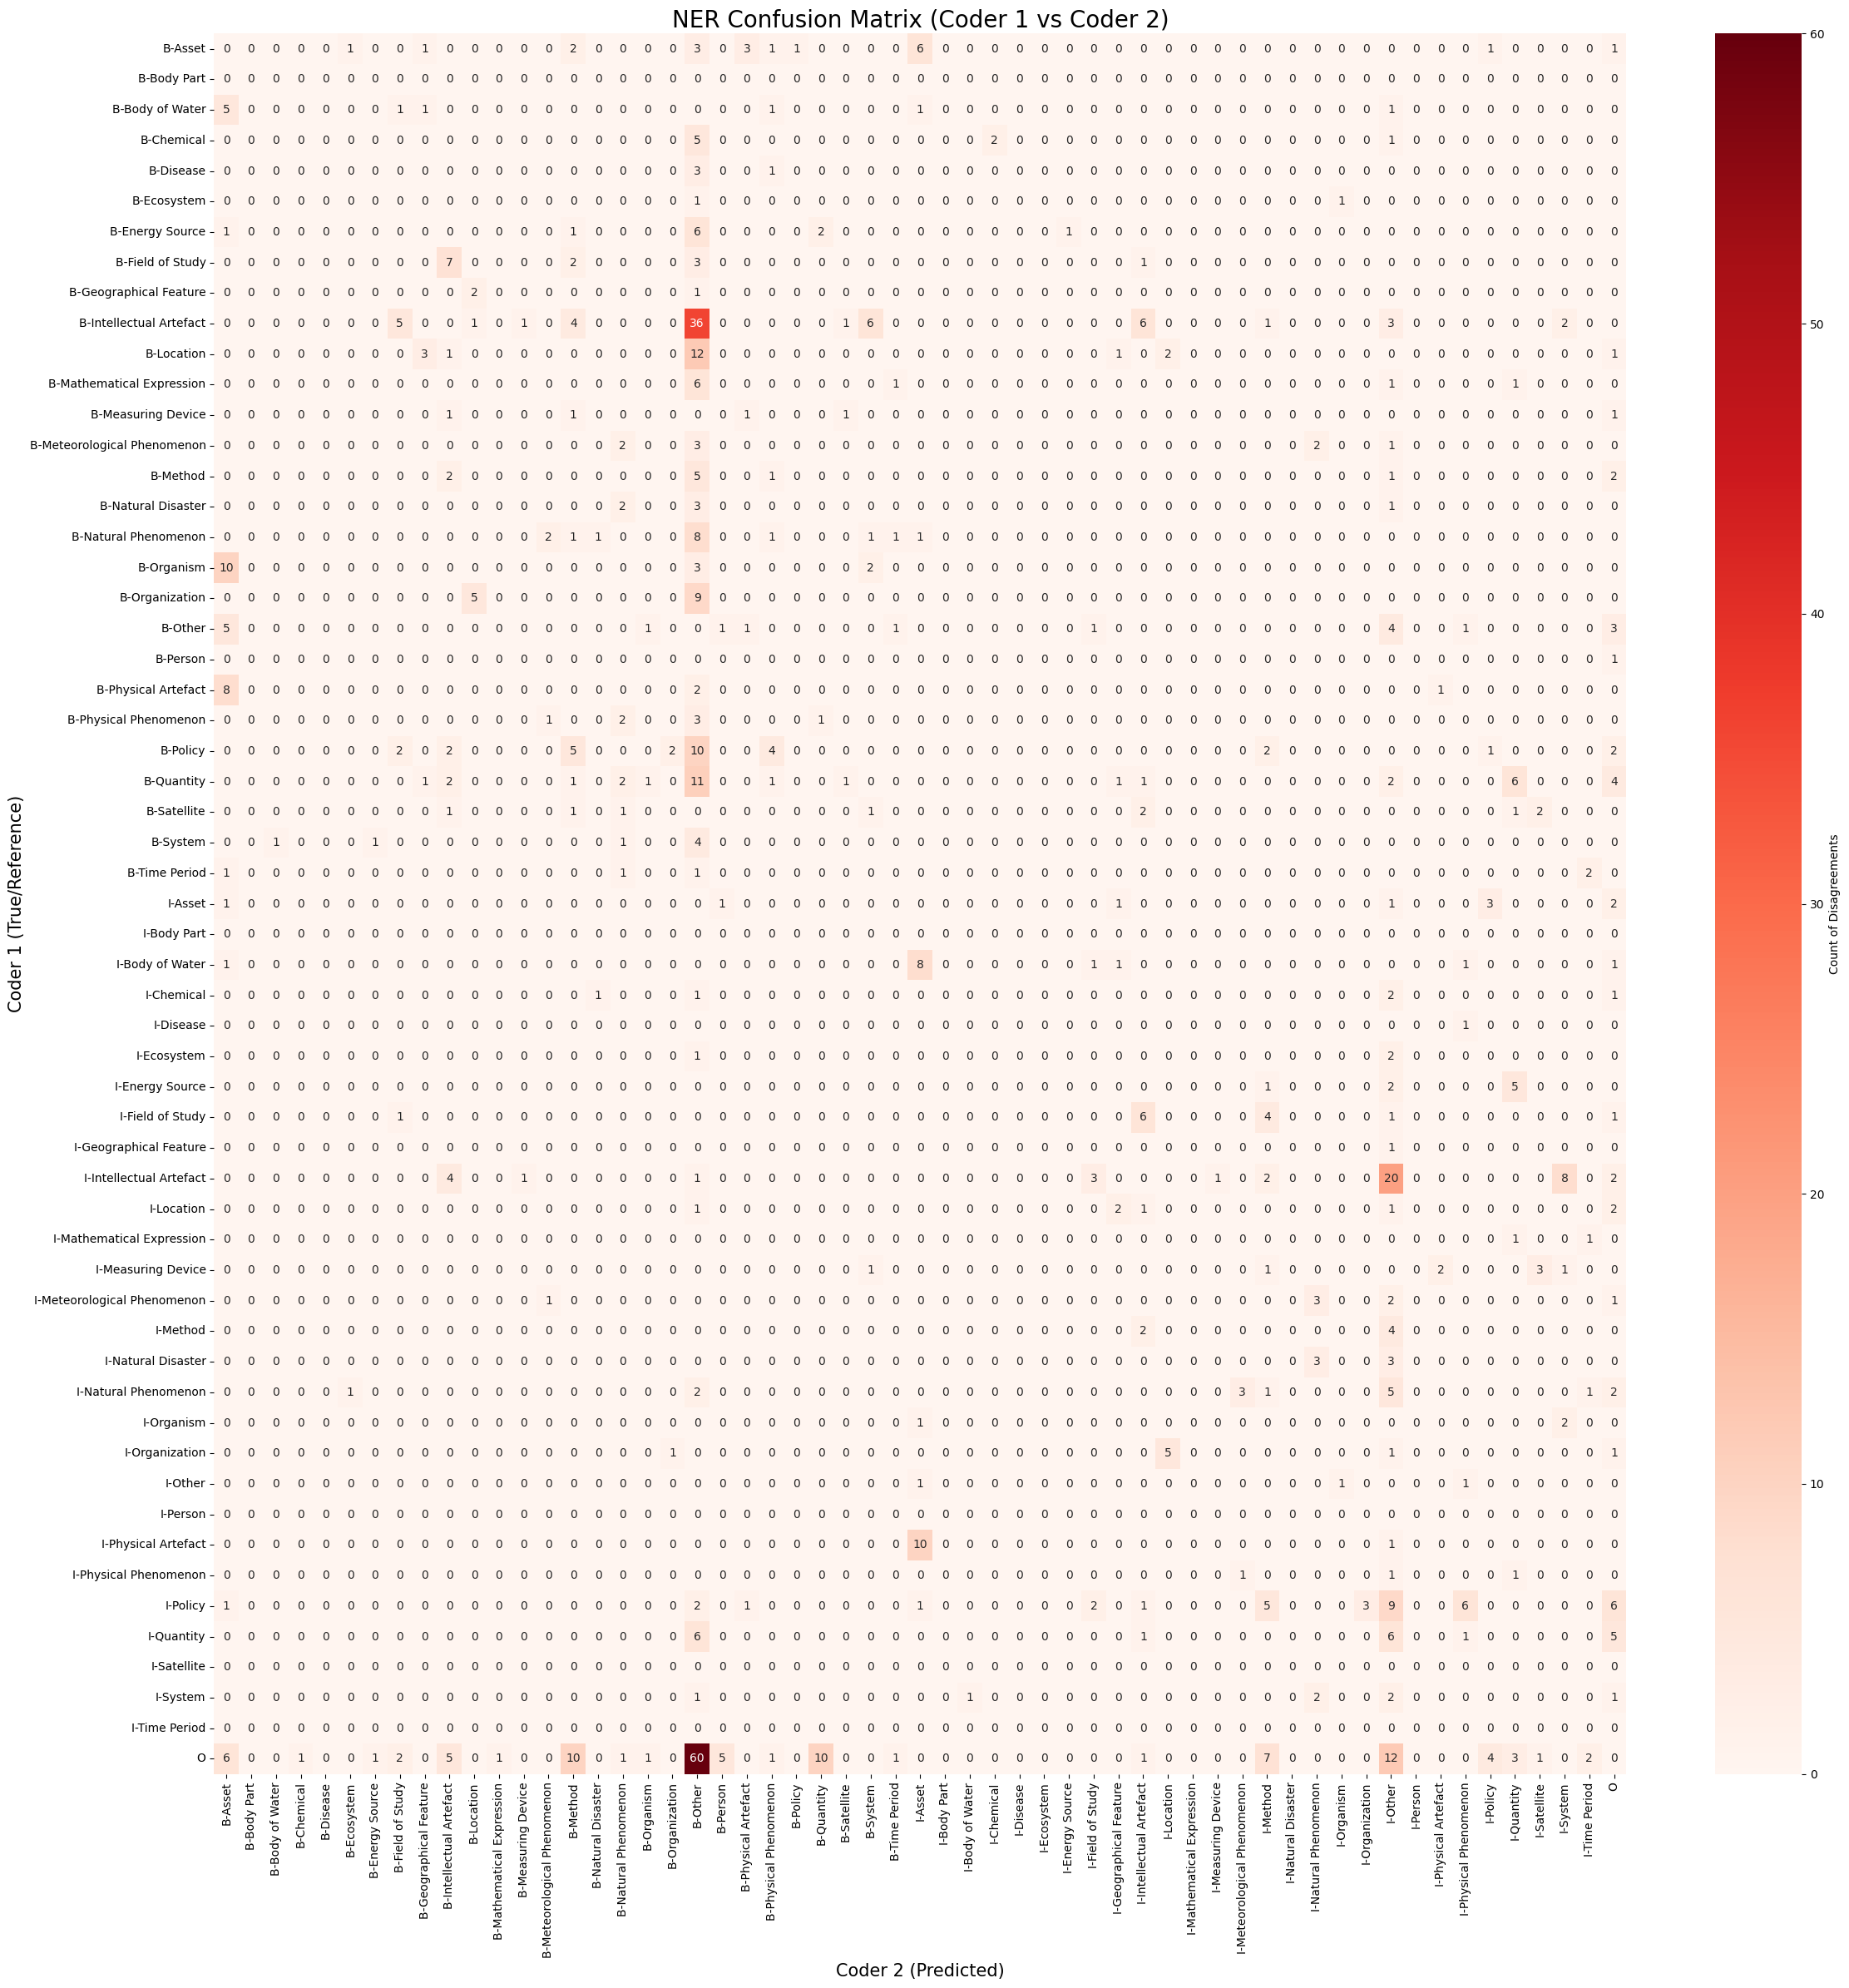

In [58]:
# 1. Run calculation
alpha, count, cm, mapping = calculate_ner_agreement(data_5, data_6)

# 2. Print results
print(f"Alpha: {alpha:.4f}")
print(f"Mapping size: {len(mapping)} tags")

# 3. Plot (using the plot function provided previously)
if cm is not None:
    plot_ner_confusion_matrix(cm, mapping, hide_diagonal=True)

In [48]:
print_top_confusions(cm, mapping, top_n=50)

Count      | Coder 1 (Row)                  -> Coder 2 (Col)                 
---------------------------------------------------------------------------
60         | O                              -> B-Other                       
37         | B-Intellectual Artefact        -> B-Other                       
20         | I-Intellectual Artefact        -> I-Other                       
19         | I-Asset                        -> I-Policy                      
19         | O                              -> I-Person                      
17         | I-Intellectual Artefact        -> B-Intellectual Artefact       
15         | B-Quantity                     -> B-Physical Phenomenon         
15         | I-Quantity                     -> I-Physical Phenomenon         
14         | O                              -> B-Intellectual Artefact       
13         | B-Asset                        -> B-Policy                      
12         | B-Intellectual Artefact        -> B-Measuring Device 

## Krippendorff for Many

In [86]:
all_coders = [
    # data_0,
    data_1,
    data_2,
    data_3,
    data_4,
    data_5,
    data_6,
    data_8,
    data_9,
    data_10,
    data_11,
    data_12
    ]

# alpha, count, cm, mapping = calculate_ner_agreement_generalized(all_coders)
alpha, count, cm, mapping =  calculate_ner_agreement_partial(all_coders)

Processing 192 documents (filtered for >=2 overlap).


In [85]:
print(f"Global Alpha: {alpha:.4f}")
# plot_ner_confusion_matrix(cm, mapping)

Global Alpha: 0.6984


## Final NER dataset

In [87]:
import uuid
import numpy as np
import krippendorff
from collections import defaultdict
from dataset_processing import CLIRENER_LABELS_V1, ANNOTATOR_EXPERT_GROUPS
import json

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import hashlib
import warnings 

import random
import copy


warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

def analyze_consensus_statistics(consensus_data, plot_graphs=True):
    """
    Analyzes the consensus dataset and prints/plots statistics.
    Compatible with both V1 (List) and V2 (Dict) span formats.
    """
    
    # --- Containers for aggregation ---
    all_alphas = []
    
    # Tie tracking
    total_ties = 0
    tie_winning_labels = []
    
    # Entity tracking
    all_entity_labels = []
    doc_entity_counts = []
    
    # Filtering stats
    docs_with_2plus_raters = 0
    high_quality_docs = 0 # > 0.66 alpha
    
    # Sentence length tracking
    token_lengths = []

    print("="*60)
    print("CONSENSUS DATASET STATISTICS")
    print("="*60)

    # --- 1. Iterate and Collect Data ---
    for doc in consensus_data:
        # Alpha
        alpha = doc.get('alpha')
        num_raters = doc.get('num_raters', 0)
        
        # Valid Alpha Logic (Exclude None and NaN)
        if alpha is not None and not np.isnan(alpha):
            all_alphas.append(alpha)
            
            # Check criteria: >= 2 raters AND Alpha > 0.66
            if num_raters >= 2:
                docs_with_2plus_raters += 1
                if alpha > 0.66:
                    high_quality_docs += 1
        
        # Entities & Ties
        doc_ent_count = 0
        tokens = doc.get('tokenized_text', [])
        token_lengths.append(len(tokens))
        
        # --- UPDATED LOOP FOR COMPATIBILITY ---
        for item in doc['ner']:
            # Handle V2 (Dictionary)
            if isinstance(item, dict):
                label = item['label']
                is_tie = item.get('tie', False)
            # Handle V1 (List/Tuple)
            else:
                # item structure: [start, end, label, is_tie, (optional_stats)]
                label = item[2]
                is_tie = item[3] if len(item) > 3 else False

            all_entity_labels.append(label)
            doc_ent_count += 1
            
            if is_tie:
                total_ties += 1
                tie_winning_labels.append(label)
        
        doc_entity_counts.append(doc_ent_count)

    # --- 2. Tie Related Statistics ---
    print(f"\n[1] TIE ANALYSIS")
    print(f"Total Confirmed Ties: {total_ties}")
    
    if tie_winning_labels:
        tie_counts = Counter(tie_winning_labels)
        most_common_tie = tie_counts.most_common(1)[0]
        print(f"Most Frequent Tie Winner: '{most_common_tie[0]}' ({most_common_tie[1]} times)")
        print("Tie Winners Distribution:")
        for label, count in tie_counts.most_common(5):
            print(f"  - {label}: {count}")
    else:
        print("No ties found.")

    # --- 3. Krippendorff's Alpha Statistics ---
    print(f"\n[2] AGREEMENT STATISTICS (Krippendorff's Alpha)")
    
    if all_alphas:
        avg_alpha = np.mean(all_alphas)
        median_alpha = np.median(all_alphas)
        print(f"Overall Average Alpha: {avg_alpha:.4f}")
        print(f"Median Alpha:        {median_alpha:.4f}")
        print(f"Min: {min(all_alphas):.4f} | Max: {max(all_alphas):.4f}")
    else:
        print("No valid alpha scores found.")

    # --- 4. General Quality Filter ---
    print(f"\n[3] DATASET QUALITY FILTER")
    print(f"Total Sentences (with valid alpha & >=2 raters): {docs_with_2plus_raters}")
    print(f"High Quality Sentences (Alpha > 0.66):           {high_quality_docs}")
    if docs_with_2plus_raters > 0:
        percent_hq = (high_quality_docs / docs_with_2plus_raters) * 100
        print(f"Yield Percentage: {percent_hq:.2f}%")

    # --- 5. Entity Statistics ---
    print(f"\n[4] ENTITY STATISTICS")
    total_entities = len(all_entity_labels)
    print(f"Total Entities Found: {total_entities}")
    print(f"Avg Entities per Sentence: {np.mean(doc_entity_counts):.2f}")
    
    entity_counts = Counter(all_entity_labels)
    
    # --- 6. Interesting Suggestions ---
    print(f"\n[5] ADDITIONAL INSIGHTS")
    
    # Suggestion A: Correlation between Sentence Length and Alpha
    if all_alphas and len(token_lengths) == len(consensus_data):
        aligned_alphas = []
        aligned_lens = []
        for doc in consensus_data:
            a = doc.get('alpha')
            if a is not None and not np.isnan(a):
                aligned_alphas.append(a)
                aligned_lens.append(len(doc.get('tokenized_text', [])))
        
        if aligned_alphas:
            corr = np.corrcoef(aligned_lens, aligned_alphas)[0, 1]
            print(f"Correlation (Length vs Agreement): {corr:.4f}")
            if corr < -0.3:
                print("  -> Trend: Longer sentences tend to have LOWER agreement.")
            elif corr > 0.3:
                print("  -> Trend: Longer sentences tend to have HIGHER agreement.")
            else:
                print("  -> Trend: No significant correlation.")

    # Suggestion B: Empty Documents
    empty_docs = doc_entity_counts.count(0)
    print(f"Documents with ZERO entities: {empty_docs} ({empty_docs/len(consensus_data)*100:.1f}%)")

    # --- PLOTTING ---
    if plot_graphs and all_alphas:
        plt.figure(figsize=(18, 10))

        # Plot 1: Alpha Distribution
        plt.subplot(2, 2, 1)
        bins = np.arange(0, 1.1, 0.1)
        sns.histplot(all_alphas, bins=bins, kde=True, color='skyblue', edgecolor='black')
        plt.title('Distribution of Krippendorff\'s Alpha')
        plt.xlabel('Alpha Score')
        plt.ylabel('Number of Sentences')
        plt.xticks(bins)
        plt.axvline(x=0.66, color='red', linestyle='--', label='High Quality Threshold (0.66)')
        plt.legend()

        # Plot 2: Entity Frequencies
        plt.subplot(2, 2, 2)
        top_labels = dict(entity_counts.most_common(28))
        if top_labels:
            sns.barplot(x=list(top_labels.values()), y=list(top_labels.keys()), hue=list(top_labels.keys()), palette='viridis')
            plt.title('Top 20 Entity Frequencies')
            plt.xlabel('Count')

        # Plot 3: Ties by Label
        if tie_winning_labels:
            plt.subplot(2, 2, 3)
            top_ties = dict(Counter(tie_winning_labels).most_common(10))
            sns.barplot(x=list(top_ties.values()), y=list(top_ties.keys()), hue=list(top_ties.keys()),  palette='magma')
            plt.title('Labels Most Often Winning Ties')
            plt.xlabel('Tie Count')

        # Plot 4: Scatter Length vs Alpha
        if 'aligned_alphas' in locals() and aligned_alphas:
            plt.subplot(2, 2, 4)
            sns.scatterplot(x=aligned_lens, y=aligned_alphas, alpha=0.6)
            sns.regplot(x=aligned_lens, y=aligned_alphas, scatter=False, color='red')
            plt.title('Sentence Length vs. Agreement')
            plt.xlabel('Token Count')
            plt.ylabel('Alpha')

        plt.tight_layout()
        plt.show()

def get_expert_mapping():
    """
    Returns a dictionary: {annotator_index: set_of_specialty_labels}
    Based on the Groups provided in the prompt.
    """
    # Define groups and their labels
    groups = ANNOTATOR_EXPERT_GROUPS

    # Invert to: {annotator_id: {set of labels}}
    expert_map = defaultdict(set)
    
    for g_name, data in groups.items():
        for annotator_id in data["annotators"]:
            expert_map[annotator_id].update(data["labels"])
            
    return expert_map

def get_shuffled_expert_mapping(seed = 42):
    """
    Maintains the Label Groups structure defined in ANNOTATOR_EXPERT_GROUPS, 
    but assigns random annotators to those groups to create a Negative Control.
    """
    
    # 1. Build the pool of unique annotators available in the configuration
    unique_annotators = set()
    for group_data in ANNOTATOR_EXPERT_GROUPS.values():
        unique_annotators.update(group_data["annotators"])
    
    # Convert to list. Sorting ensures the seed always produces the same shuffle order.
    annotator_pool = sorted(list(unique_annotators))
    
    # 2. Shuffle the people
    # Seed 42 for reproducibility of the "Wrong" map
    random.seed(seed) 
    shuffled_pool = annotator_pool[:]
    random.shuffle(shuffled_pool)
    
    # 3. Assign shuffled people to the fixed buckets
    shuffled_map = defaultdict(set)
    pool_cursor = 0
    
    print("--- Randomized Expert Assignments (Negative Control) ---")
    
    for group_name, group_data in ANNOTATOR_EXPERT_GROUPS.items():
        # How many slots does this group need? (e.g. G1 needs 2, G6 needs 3)
        count_needed = len(group_data["annotators"])
        labels = group_data["labels"]
        
        assigned_ids = []
        for _ in range(count_needed):
            # We use modulus (%) here because there are 12 slots but only 11 unique humans.
            # This ensures someone (randomly) gets double-duty, just like Annotator 5 originally.
            ann_id = shuffled_pool[pool_cursor % len(shuffled_pool)]
            assigned_ids.append(ann_id)
            pool_cursor += 1
            
        print(f"Group {group_name} Labels assigned to Fake Experts: {assigned_ids}")
        
        # Build the map
        for ann_id in assigned_ids:
            shuffled_map[ann_id].update(labels)
            
    return shuffled_map

def generate_consensus_dataset(list_of_annotator_data, weights=(1.0, 0.7), o_weight=None):
    """
    Generates a ground truth dataset using Weighted Expert Voting.
    
    Args:
        list_of_annotator_data: List where index i contains data for Annotator i.
        weights: Tuple (expert_weight, non_expert_weight). Default (1.0, 0.7).
        o_weight: Specific weight for the 'O' tag. 
                  If None, defaults to non_expert_weight (weights[1]).
                  Set higher (e.g. 0.9 or 1.0) to make the model more conservative (Precision).
                  Set lower (e.g. 0.3) to make the model more aggressive (Recall).
    """
    expert_weight, non_expert_weight = weights
    
    # Set default O weight if not provided
    final_o_weight = o_weight if o_weight is not None else non_expert_weight
    
    expert_map = get_expert_mapping()
    label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)
    
    aligned_docs = defaultdict(dict)
    for ann_idx, dataset in enumerate(list_of_annotator_data):
        if dataset is None: continue 
        for doc in dataset:
            aligned_docs[doc['id']][ann_idx] = doc

    consensus_dataset = []
    print(f"Processing consensus for {len(aligned_docs)} unique documents...")
    print(f"Configuration: Expert={expert_weight}, Non-Expert={non_expert_weight}, O-Tag={final_o_weight}")

    for doc_id, ann_data_map in aligned_docs.items():
        ref_doc = list(ann_data_map.values())[0]
        tokens = ref_doc['tokenized_text']
        doc_len = len(tokens)

        # 1. Calculate Alpha
        doc_alpha = calculate_single_document_alpha(doc_id, ann_data_map, label_map)

        # 2. Collect Tags
        annotator_tags = {}
        for ann_idx, doc in ann_data_map.items():
            if len(doc['tokenized_text']) == doc_len:
                annotator_tags[ann_idx] = spans_to_bio_tags(tokens, doc['ner'])

        # Count actual raters
        num_raters = len(annotator_tags)

        final_tags = []
        token_ties = []

        # 3. Vote
        for t_i in range(doc_len):
            scores = defaultdict(float)
            for ann_idx, tags_list in annotator_tags.items():
                tag = tags_list[t_i]
                
                # --- NEW WEIGHTING LOGIC ---
                if tag == "O":
                    w = final_o_weight
                else:
                    label_core = tag[2:] # Strip B- or I-
                    # Check expert status for this specific label
                    if label_core in expert_map.get(ann_idx, set()):
                        w = expert_weight
                    else:
                        w = non_expert_weight
                
                scores[tag] += w
            
            if not scores:
                final_tags.append("O")
                token_ties.append(False)
            else:
                candidates = list(scores.items())
                
                # Sort: 
                # 1. Score (Desc)
                # 2. Entity Preference: Is 'O'? (False < True). 
                #    If scores are equal, Entity (0) wins over O (1).
                # 3. Alphabetical
                candidates.sort(key=lambda x: (-x[1], x[0] == "O", x[0]))
                
                winner = candidates[0][0]
                final_tags.append(winner)
                
                is_tie = False
                if len(candidates) > 1 and candidates[0][1] == candidates[1][1]:
                    is_tie = True
                token_ties.append(is_tie)

        # 4. Post-Process (Fix Broken Sequences)
        cleaned_tags = []
        for i, tag in enumerate(final_tags):
            if tag.startswith("I-"):
                label = tag[2:]
                prev_tag = cleaned_tags[i-1] if i > 0 else "O"
                expected_prev_b = f"B-{label}"
                expected_prev_i = f"I-{label}"
                
                if prev_tag not in [expected_prev_b, expected_prev_i]:
                    cleaned_tags.append(f"B-{label}")
                else:
                    cleaned_tags.append(tag)
            else:
                cleaned_tags.append(tag)

        consensus_spans = bio_tags_to_spans_with_ties(cleaned_tags, token_ties)
        
        consensus_doc = {
            "id": doc_id,
            "text": ref_doc.get("text", ""),
            "tokenized_text": tokens,
            "ner": consensus_spans,
            "alpha": doc_alpha,
            "num_raters": num_raters
        }
        consensus_dataset.append(consensus_doc)

    return consensus_dataset

def generate_consensus_dataset_v2(list_of_annotator_data, weights=(1.0, 0.7), o_weight=None, expert_map=None):
    expert_weight, non_expert_weight = weights
    final_o_weight = o_weight if o_weight is not None else non_expert_weight
    if type(expert_map) == type(None):
        expert_map = get_expert_mapping()
        
    # print(expert_map)
    label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)
    
    aligned_docs = defaultdict(dict)
    for ann_idx, dataset in enumerate(list_of_annotator_data):
        if dataset is None: continue 
        for doc in dataset:
            aligned_docs[doc['id']][ann_idx] = doc

    consensus_dataset = []

    for doc_id, ann_data_map in aligned_docs.items():
        ref_doc = list(ann_data_map.values())[0]
        tokens = ref_doc['tokenized_text']
        doc_len = len(tokens)
        doc_alpha = calculate_single_document_alpha(doc_id, ann_data_map, label_map)
        annotator_tags = {}
        for ann_idx, doc in ann_data_map.items():
            if len(doc['tokenized_text']) == doc_len:
                annotator_tags[ann_idx] = spans_to_bio_tags(tokens, doc['ner'])
        
        num_raters = len(annotator_tags)
        final_tags = []
        token_ties = []
        token_scores = []

        # =========================================================
        # 1. Vote per token (Two-Stage Voting)
        # =========================================================
        for t_i in range(doc_len):
            bio_scores = defaultdict(float)      
            semantic_scores = defaultdict(float) 

            for ann_idx, tags_list in annotator_tags.items():
                tag = tags_list[t_i]
                if tag == "O":
                    w = final_o_weight
                    label_core = "O"
                else:
                    label_core = tag[2:] 
                    if label_core in expert_map.get(ann_idx, set()):
                        w = expert_weight
                    else:
                        w = non_expert_weight
                
                bio_scores[tag] += w
                semantic_scores[label_core] += w
            
            token_scores.append(dict(bio_scores))

            if not semantic_scores:
                final_tags.append("O")
                token_ties.append(False)
                continue

            candidates = list(semantic_scores.items())
            candidates.sort(key=lambda x: (-x[1], x[0] == "O", x[0]))
            
            winning_category = candidates[0][0]
            
            is_tie = False
            if len(candidates) > 1 and candidates[0][1] == candidates[1][1]:
                is_tie = True
            token_ties.append(is_tie)

            if winning_category == "O":
                final_tags.append("O")
            else:
                b_tag = f"B-{winning_category}"
                i_tag = f"I-{winning_category}"
                # Winner takes all for boundary
                if bio_scores.get(b_tag, 0.0) >= bio_scores.get(i_tag, 0.0):
                    final_tags.append(b_tag)
                else:
                    final_tags.append(i_tag)

        # =========================================================
        # 2. Post-process tags (Consistency)
        # =========================================================
        cleaned_tags = []
        for i, tag in enumerate(final_tags):
            if tag.startswith("I-"):
                label = tag[2:]
                prev = cleaned_tags[i-1] if i > 0 else "O"
                if prev not in [f"B-{label}", f"I-{label}"]:
                    cleaned_tags.append(f"B-{label}")
                else:
                    cleaned_tags.append(tag)
            else:
                cleaned_tags.append(tag)

        # =========================================================
        # 3. Create Spans
        # =========================================================
        consensus_spans = bio_tags_to_spans_with_ties(cleaned_tags, token_ties)
        
        # 4. ENRICH SPANS WITH VOTE STATS
        # Adjusted for List Format: [start, end_inclusive, label, tie, stats]
        for span in consensus_spans:
            s = span[0]
            e_inclusive = span[1] # Inclusive
            
            span_vote_sum = defaultdict(float)
            
            # Use range(s, e + 1) because e is inclusive
            for t_idx in range(s, e_inclusive + 1):
                t_scores = token_scores[t_idx]
                for tag, val in t_scores.items():
                    clean_lbl = tag[2:] if tag != "O" else "O"
                    span_vote_sum[clean_lbl] += val
            
            # Normalize
            current_span_len = max(1, (e_inclusive - s) + 1)
            stats = {k: round(v/current_span_len, 2) for k, v in span_vote_sum.items()}
            
            # Append stats as the 5th element
            span.append(stats)

        consensus_dataset.append({
            "id": doc_id,
            "text": ref_doc.get("text", ""),
            "tokenized_text": tokens,
            "ner": consensus_spans,
            "num_raters": num_raters,
            "alpha": doc_alpha,
            "scores": token_scores
        })

    return consensus_dataset


def bio_tags_to_spans_with_ties(tags, token_ties):
    """ 
    Converts BIO tags and a parallel list of booleans (is_tie) into spans.
    Returns: [[start_token_idx, end_token_idx, label, is_tie_boolean], ...]
    """
    spans = []
    current_start = None
    current_label = None
    
    for i, tag in enumerate(tags):
        if tag.startswith("B-"):
            if current_label is not None:
                # Check if any token in the previous span was a tie
                span_tie = any(token_ties[current_start : i])
                spans.append([current_start, i - 1, current_label, span_tie])
            
            current_start = i
            current_label = tag[2:]
            
        elif tag.startswith("I-"):
            new_label = tag[2:]
            if current_label is None:
                current_start = i
                current_label = new_label
            elif current_label != new_label:
                # Label switch
                span_tie = any(token_ties[current_start : i])
                spans.append([current_start, i - 1, current_label, span_tie])
                current_start = i
                current_label = new_label
                
        else: # "O"
            if current_label is not None:
                span_tie = any(token_ties[current_start : i])
                spans.append([current_start, i - 1, current_label, span_tie])
                current_label = None
                current_start = None

    if current_label is not None:
        span_tie = any(token_ties[current_start : len(tags)])
        spans.append([current_start, len(tags) - 1, current_label, span_tie])
        
    return spans

def calculate_single_document_alpha(doc_id, annotator_map, label_map):
    """
    Calculates Krippendorff's Alpha for a single document.
    annotator_map: {annotator_index: doc_data_dict}
    """
    if len(annotator_map) < 2:
        return None  # Cannot calculate alpha with < 2 coders
    
    # Get reference tokens
    first_ann = list(annotator_map.values())[0]
    tokens = first_ann['tokenized_text']
    
    # Prepare matrix: Rows = Annotators, Cols = Tokens
    # Note: We must map annotator indices to rows 0..N consistently
    encoded_rows = []
    
    for ann_idx, doc_data in annotator_map.items():
        if len(doc_data['tokenized_text']) != len(tokens):
            return None # Token mismatch
        
        try:
            tags = spans_to_bio_tags(tokens, doc_data['ner'])
            encoded_vals = [label_map[t] for t in tags]
            encoded_rows.append(encoded_vals)
        except KeyError:
            return None

    reliability_data = np.array(encoded_rows)
    
    # Calculate Alpha
    # Handle the case where there is NO variance (everyone agrees perfectly)
    try:
        alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement="nominal")
        return alpha
    except:
        return 0.0

def get_token_char_offsets(text, tokens):
    """
    Reconstructs character start/end for tokens based on the raw text.
    Returns a list of tuples: [(start_char, end_char), ...]
    """
    offsets = []
    current_pos = 0
    text_lower = text.lower()
    
    for token in tokens:
        # Simple finder - assumes tokens appear in order
        # You might need a more robust tokenizer alignment if your tokens are drastically normalized
        token_str = token.lower()
        start = text_lower.find(token_str, current_pos)
        
        if start == -1:
            # Fallback: if token not found (e.g. specialized chars), skip or estimate
            # This is a common pain point. We'll assume strict alignment for now.
            offsets.append((current_pos, current_pos + len(token)))
            current_pos += len(token)
        else:
            end = start + len(token)
            offsets.append((start, end))
            current_pos = end
            
    return offsets

def convert_consensus_to_labelstudio(consensus_data, model_version="Consensus_Voting_v1"):
    """
    Args:
        consensus_data: List of dicts from generate_consensus_dataset (v1 or v2)
    """
    labelstudio_data = []
    
    for doc in consensus_data:
        text = doc['text']
        tokens = doc['tokenized_text']
        alpha_score = doc.get('alpha')
        num_raters = doc.get('num_raters', 0)
        raw_id = str(doc['id'])
        
        # Parse Paper ID and Sentence ID
        if '-' in raw_id:
            paper_id, sentence_id = raw_id.rsplit('-', 1)
        else:
            paper_id = raw_id
            sentence_id = "N/A"

        # Generate mapping from token index to character offsets
        # Ensure get_token_char_offsets is available in your scope
        token_char_map = get_token_char_offsets(text, tokens)
        
        results = []
        
        # Iterate through spans using dynamic unpacking to handle V1 (List) and V2 (Dict/List+Stats)
        for item in doc['ner']:
            vote_stats = None
            
            # --- CASE 1: Item is a Dictionary (Likely V2 from Visualizer) ---
            if isinstance(item, dict):
                start_tok = item['start']
                end_tok = item['end']
                label = item['label']
                is_tie = item.get('tie', False)
                vote_stats = item.get('vote_stats', None)
            
            # --- CASE 2: Item is a List/Tuple (Likely V1 or V2 backend) ---
            else:
                # Basic unpacking
                start_tok = item[0]
                end_tok = item[1]
                label = item[2]
                is_tie = item[3] if len(item) > 3 else False
                
                # Check for V2 extra data (vote_stats) in the list
                if len(item) > 4:
                    vote_stats = item[4]

            # --- Calculate Character Offsets ---
            # Safety check to ensure indices are within bounds of the char map
            if start_tok < len(token_char_map) and end_tok < len(token_char_map):
                start_char = token_char_map[start_tok][0]
                end_char = token_char_map[end_tok][1]
                chunk_text = text[start_char:end_char]
                
                # Build Meta Data (Include ties and detailed stats if available)
                meta_data = {
                    "is_tie": is_tie,
                    "score": 0.5 if is_tie else 1.0 
                }
                if vote_stats:
                    meta_data["vote_stats"] = vote_stats

                results.append({
                    "id": str(uuid.uuid4())[:8],
                    "from_name": "label",
                    "to_name": "text",
                    "type": "labels",
                    "value": {
                        "start": start_char,
                        "end": end_char,
                        "text": chunk_text,
                        "labels": [label]
                    },
                    "meta": meta_data
                })
            
        prediction_entry = {
            "model_version": model_version,
            "score": 1.0, 
            "result": results
        }

        # Format Alpha for display
        if alpha_score is None or np.isnan(alpha_score):
            display_alpha = "N/A"
        else:
            display_alpha = float(round(alpha_score, 4))

        ls_entry = {
            "data": {
                "sentence": text,
                "id": raw_id,
                "paper_id": paper_id,        
                "sentence_id": sentence_id,  
                "num_raters": num_raters,    
                "alpha_agreement": display_alpha
            },
            "predictions": [prediction_entry]
        }
        
        labelstudio_data.append(ls_entry)
        
    return labelstudio_data


def load_precomputed_frequencies(filepath="label_frequencies.json"):
    """
    Loads the precomputed label frequencies from a local JSON file.
    """
    try:
        with open(filepath, "r") as f:
            frequencies = json.load(f)
            print(f"✅ Loaded prior frequencies for {len(frequencies)} labels.")
            return frequencies
    except FileNotFoundError:
        print(f"⚠️ {filepath} not found. Please run precompute_frequencies.py first.")
        return {}
    except Exception as e:
        print(f"⚠️ Error loading frequencies: {e}")
        return {}
    
def stable_random_tiebreaker(doc_id, token_idx, label):
    """
    Creates a mathematically fair, 100% reproducible random integer
    based on the exact location in the document and the label name.
    """
    hash_str = f"{doc_id}_{token_idx}_{label}"
    return int(hashlib.md5(hash_str.encode()).hexdigest(), 16)

def generate_consensus_dataset_v3(list_of_annotator_data, weights=(1.0, 0.7), o_weight=None, expert_map=None):
    expert_weight, non_expert_weight = weights
    final_o_weight = o_weight if o_weight is not None else non_expert_weight
    
    if expert_map is None:
        expert_map = get_expert_mapping()
        
    label_map = generate_consistent_label_map(CLIRENER_LABELS_V1)
    
    # Load the data-driven prior from the local JSON file
    label_frequencies = load_precomputed_frequencies("label_frequencies.json")
    
    aligned_docs = defaultdict(dict)
    for ann_idx, dataset in enumerate(list_of_annotator_data):
        if dataset is None: continue 
        for doc in dataset:
            aligned_docs[doc['id']][ann_idx] = doc

    consensus_dataset =[]

    for doc_id, ann_data_map in aligned_docs.items():
        ref_doc = list(ann_data_map.values())[0]
        tokens = ref_doc['tokenized_text']
        doc_len = len(tokens)
        doc_alpha = calculate_single_document_alpha(doc_id, ann_data_map, label_map)
        annotator_tags = {}
        for ann_idx, doc in ann_data_map.items():
            if len(doc['tokenized_text']) == doc_len:
                annotator_tags[ann_idx] = spans_to_bio_tags(tokens, doc['ner'])
        
        num_raters = len(annotator_tags)
        final_tags =[]
        token_ties = []
        token_scores =[]

        # =========================================================
        # 1. Vote per token (Two-Stage Voting)
        # =========================================================
        for t_i in range(doc_len):
            bio_scores = defaultdict(float)      
            semantic_scores = defaultdict(float) 

            for ann_idx, tags_list in annotator_tags.items():
                tag = tags_list[t_i]
                if tag == "O":
                    w = final_o_weight
                    label_core = "O"
                else:
                    label_core = tag[2:] 
                    if label_core in expert_map.get(ann_idx, set()):
                        w = expert_weight
                    else:
                        w = non_expert_weight
                
                bio_scores[tag] += w
                semantic_scores[label_core] += w
            
            token_scores.append(dict(bio_scores))

            if not semantic_scores:
                final_tags.append("O")
                token_ties.append(False)
                continue

            candidates = list(semantic_scores.items())
            
            # --- THE NEW UNBIASED HIERARCHICAL TIE-BREAKER ---
            candidates.sort(key=lambda x: (
                -x[1],                                      # 1. Highest numeric vote score
                x[0] == "O",                                # 2. Real entities beat "O" tag
                label_frequencies.get(x[0], 999999),        # 3. Rarer label wins (Information Theory heuristic)
                stable_random_tiebreaker(doc_id, t_i, x[0]) # 4. Hash fallback (Eliminates alphabetical bias)
            ))
            
            winning_category = candidates[0][0]
            
            is_tie = False
            if len(candidates) > 1 and candidates[0][1] == candidates[1][1]:
                is_tie = True
            token_ties.append(is_tie)

            if winning_category == "O":
                final_tags.append("O")
            else:
                b_tag = f"B-{winning_category}"
                i_tag = f"I-{winning_category}"
                # Winner takes all for boundary
                if bio_scores.get(b_tag, 0.0) >= bio_scores.get(i_tag, 0.0):
                    final_tags.append(b_tag)
                else:
                    final_tags.append(i_tag)

        # =========================================================
        # 2. Post-process tags (Consistency)
        # =========================================================
        cleaned_tags =[]
        for i, tag in enumerate(final_tags):
            if tag.startswith("I-"):
                label = tag[2:]
                prev = cleaned_tags[i-1] if i > 0 else "O"
                if prev not in[f"B-{label}", f"I-{label}"]:
                    cleaned_tags.append(f"B-{label}")
                else:
                    cleaned_tags.append(tag)
            else:
                cleaned_tags.append(tag)

        # =========================================================
        # 3. Create Spans
        # =========================================================
        consensus_spans = bio_tags_to_spans_with_ties(cleaned_tags, token_ties)
        
        # 4. ENRICH SPANS WITH VOTE STATS
        for span in consensus_spans:
            s = span[0]
            e_inclusive = span[1] # Inclusive
            
            span_vote_sum = defaultdict(float)
            
            for t_idx in range(s, e_inclusive + 1):
                t_scores = token_scores[t_idx]
                for tag, val in t_scores.items():
                    clean_lbl = tag[2:] if tag != "O" else "O"
                    span_vote_sum[clean_lbl] += val
            
            current_span_len = max(1, (e_inclusive - s) + 1)
            stats = {k: round(v/current_span_len, 2) for k, v in span_vote_sum.items()}
            
            span.append(stats)

        consensus_dataset.append({
            "id": doc_id,
            "text": ref_doc.get("text", ""),
            "tokenized_text": tokens,
            "ner": consensus_spans,
            "num_raters": num_raters,
            "alpha": doc_alpha,
            "scores": token_scores
        })

    return consensus_dataset



In [88]:
all_annotators = [None, data_1, data_2, data_3, data_4, data_5, 
                  data_6, data_7, data_8, data_9, data_10, data_11, data_12]

# 1. Generate Consensus
consensus_data = generate_consensus_dataset_v3(all_annotators, weights=(1.1, 0.9), o_weight=1, expert_map=None)

# 2. Convert to Label Studio
ls_json = convert_consensus_to_labelstudio(consensus_data)

# 3. Save

with open("consensus_for_labelstudio_adjustedvote_5326_v0.json", "w") as f:
    json.dump(ls_json, f, indent=2)

✅ Loaded prior frequencies for 28 labels.


CONSENSUS DATASET STATISTICS

[1] TIE ANALYSIS
Total Confirmed Ties: 211
Most Frequent Tie Winner: 'Asset' (20 times)
Tie Winners Distribution:
  - Asset: 20
  - Physical Phenomenon: 17
  - Field of Study: 17
  - Mathematical Expression: 14
  - Intellectual Artefact: 14

[2] AGREEMENT STATISTICS (Krippendorff's Alpha)
Overall Average Alpha: 0.6747
Median Alpha:        0.6761
Min: 0.2618 | Max: 1.0000

[3] DATASET QUALITY FILTER
Total Sentences (with valid alpha & >=2 raters): 192
High Quality Sentences (Alpha > 0.66):           103
Yield Percentage: 53.65%

[4] ENTITY STATISTICS
Total Entities Found: 2469
Avg Entities per Sentence: 12.86

[5] ADDITIONAL INSIGHTS
Correlation (Length vs Agreement): 0.0473
  -> Trend: No significant correlation.
Documents with ZERO entities: 0 (0.0%)


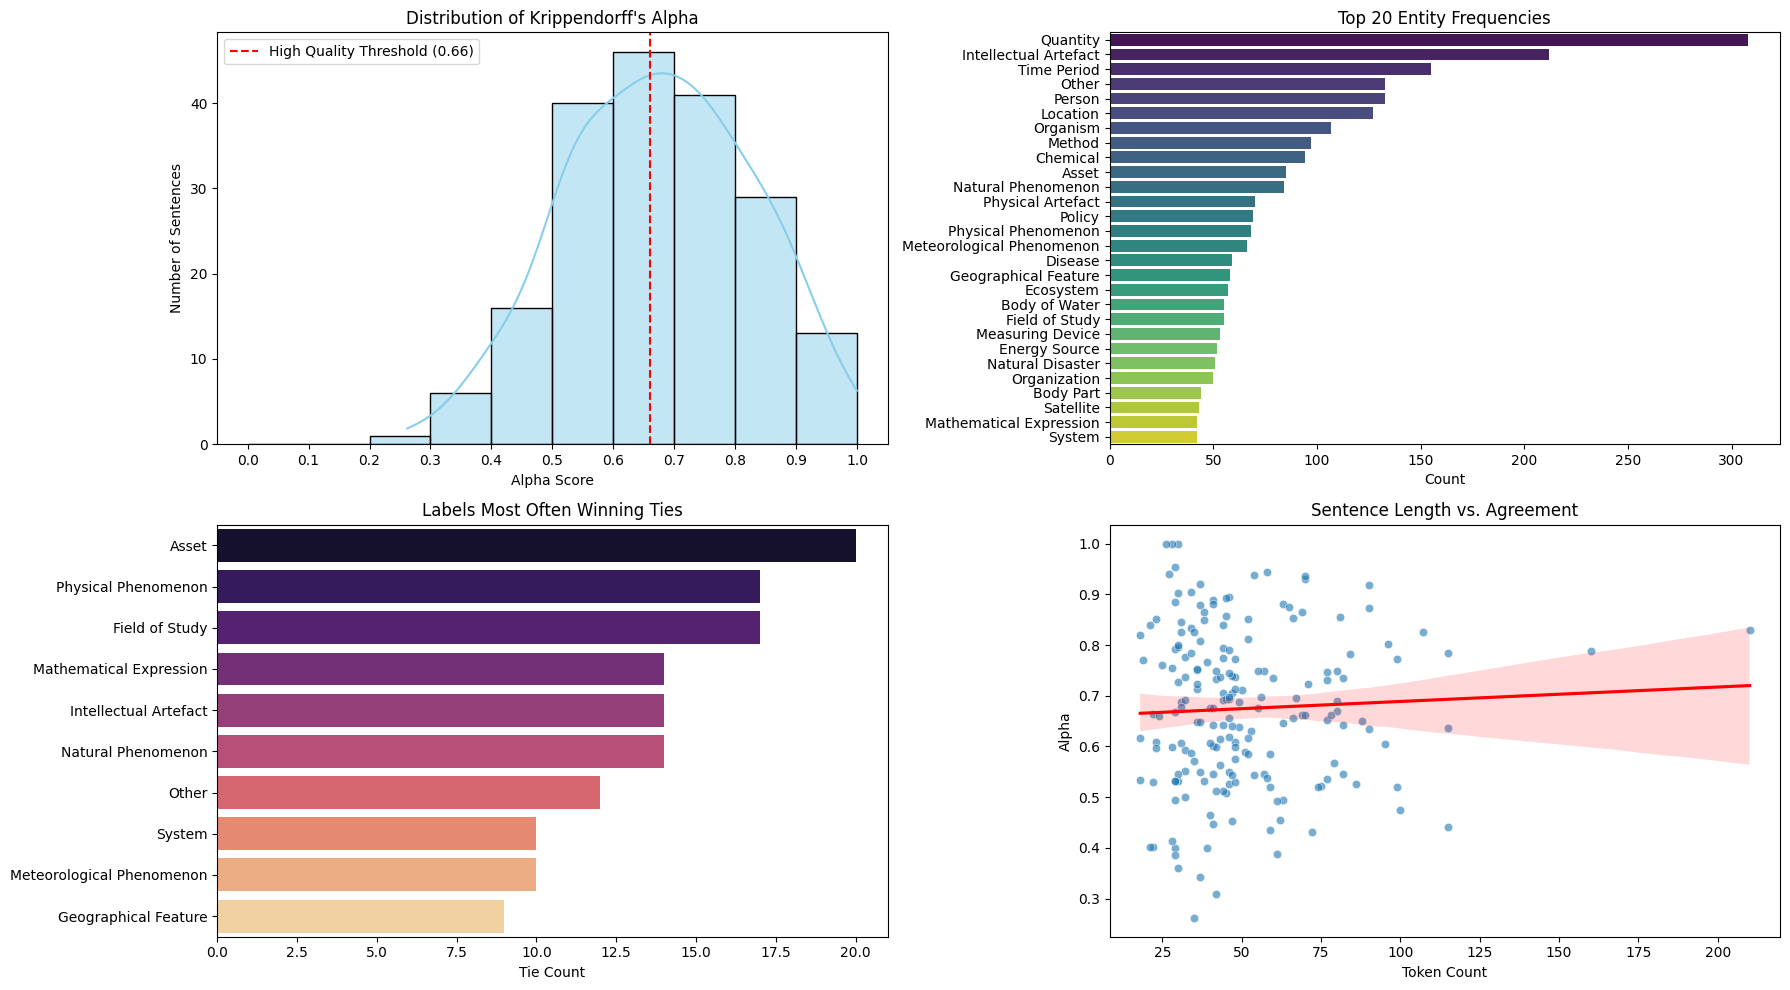

In [11]:
# --- Usage ---
analyze_consensus_statistics(consensus_data)

## Final NER Dataset Grouoping Experiment

In [ ]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm  # For progress bars
from nltk.metrics.agreement import AnnotationTask

all_annotators = [None, data_1, data_2, data_3, data_4, data_5, 
                  data_6, data_7, data_8, data_9, data_10, data_11, data_12]
# ==========================================
# 1. SETUP & HELPER FUNCTIONS
# ==========================================

# Redefine to accept seed
def get_shuffled_expert_mapping(seed):
    """
    Returns a shuffled expert map based on a specific random seed.
    """
    # 1. Build pool
    unique_annotators = set()
    for group_data in ANNOTATOR_EXPERT_GROUPS.values():
        unique_annotators.update(group_data["annotators"])
    annotator_pool = sorted(list(unique_annotators))
    
    # 2. Shuffle with specific seed
    rng = random.Random(seed)
    shuffled_pool = annotator_pool[:]
    rng.shuffle(shuffled_pool)
    
    # 3. Assign
    shuffled_map = defaultdict(set)
    pool_cursor = 0
    
    for group_name, group_data in ANNOTATOR_EXPERT_GROUPS.items():
        count_needed = len(group_data["annotators"])
        labels = group_data["labels"]
        
        assigned_ids = []
        for _ in range(count_needed):
            ann_id = shuffled_pool[pool_cursor % len(shuffled_pool)]
            assigned_ids.append(ann_id)
            pool_cursor += 1
            
        for ann_id in assigned_ids:
            shuffled_map[ann_id].update(labels)
            
    return shuffled_map

def calculate_kappa_quiet(data_0, data_1):
    """
    A silent version of the agreement calculator for batch processing.
    Returns Cohen's Kappa (float).
    Handles ZeroDivisionError for cases of perfect agreement on monotonic data.
    """
    nltk_formatted_data = []
    
    dict_c1 = {d['id']: d for d in data_0}
    dict_c2 = {d['id']: d for d in data_1}
    
    common_ids = set(dict_c1.keys()).intersection(set(dict_c2.keys()))
    if not common_ids: return 0.0
    
    for doc_id in sorted(common_ids):
        doc_0 = dict_c1[doc_id]
        doc_1 = dict_c2[doc_id]
        tokens = doc_0['tokenized_text']
        
        # Annotator 0
        tags_0 = spans_to_bio_tags(tokens, doc_0['ner']) if doc_0['ner'] else ["O"] * len(tokens)
        for idx, tag in enumerate(tags_0):
            nltk_formatted_data.append(('ann_0', f"{doc_id}_{idx}", tag))

        # Annotator 1
        tags_1 = spans_to_bio_tags(tokens, doc_1['ner']) if doc_1['ner'] else ["O"] * len(tokens)
        for idx, tag in enumerate(tags_1):
            nltk_formatted_data.append(('ann_1', f"{doc_id}_{idx}", tag))

    task = AnnotationTask(data=nltk_formatted_data)
    
    try:
        return task.kappa()
    except ZeroDivisionError:
        # This happens if Ae == 1.0 (e.g., both annotators marked EVERYTHING as 'O').
        # In a stability context, identical behavior = 1.0 agreement.
        return 1.0

# ==========================================
# 2. RUN EXPERIMENT (GENERATION PHASE)
# ==========================================

# Prepare inputs
# Assuming 'all_annotators' is already loaded in your environment
# all_annotators = [data_1, data_2, ...] 

experiment_results = []
run_labels = []

# Define experiment parameters
NUM_RANDOM_RUNS = 9
TOTAL_RUNS = 1 + NUM_RANDOM_RUNS  # 1 Original + 99 Random

print(f"🚀 Starting Experiment: 1 Original Run vs {NUM_RANDOM_RUNS} Randomized Runs")

for i in tqdm(range(TOTAL_RUNS), desc="Generating Consensus Datasets"):
    if i == 0:
        # --- RUN 0: ORIGINAL (BASELINE) ---
        label = "Original"
        # Pass None to use the default get_expert_mapping() inside the function
        # OR explicitly pass get_expert_mapping()
        consensus_data = generate_consensus_dataset_v3(
            all_annotators, 
            weights=(1.1, 0.9), 
            o_weight=1, 
            expert_map=get_expert_mapping() 
        )
    else:
        # --- RUN N: SHUFFLED ---
        label = f"Seed {i}"
        # Generate map based on seed i
        fake_map = get_shuffled_expert_mapping(seed=i)
        consensus_data = generate_consensus_dataset_v3(
            all_annotators, 
            weights=(1.1, 1.1), 
            o_weight=1, 
            expert_map=fake_map
        )
    
    # Store raw data for calculation (No need to convert to LS JSON for the math)
    experiment_results.append(consensus_data)
    run_labels.append(label)

# ==========================================
# 3. ANALYSIS PHASE (MATRIX CALCULATION)
# ==========================================

print("\n🧮 Calculating Kappa Matrix (100x100)...")
kappa_matrix = np.zeros((TOTAL_RUNS, TOTAL_RUNS))

# We only calculate the upper triangle to save 50% time, then mirror it
for i in tqdm(range(TOTAL_RUNS), desc="Rows"):
    for j in range(i, TOTAL_RUNS):
        if i == j:
            kappa = 1.0
        else:
            kappa = calculate_kappa_quiet(experiment_results[i], experiment_results[j])
        
        kappa_matrix[i, j] = kappa
        kappa_matrix[j, i] = kappa

# ==========================================
# 4. VISUALIZATION
# ==========================================

plt.figure(figsize=(20, 18))

# Mask the diagonal to make colors stand out better (optional, comment out if unwanted)
mask = np.eye(TOTAL_RUNS, dtype=bool)

# Create Heatmap
ax = sns.heatmap(
    kappa_matrix, 
    cmap="viridis", 
    square=True,
    xticklabels=False, # Hide labels for cleaner look (too many seeds)
    yticklabels=False,
    cbar_kws={"label": "Cohen's Kappa Agreement"}
)

# Custom Labeling for the "Original" run
# We want the first row/col to stand out
plt.title("Stability Analysis: Original Heuristic vs. 99 Randomized Permutations", fontsize=20)
plt.xlabel("Simulation Runs (Index 0 = Original)", fontsize=15)
plt.ylabel("Simulation Runs (Index 0 = Original)", fontsize=15)

# Highlight Index 0 manually
plt.text(0.5, -1, "Original", color='red', ha='center', fontweight='bold', fontsize=12)
plt.text(-1, 0.5, "Original", color='red', va='center', rotation=90, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 5. SUMMARY STATS PRINT
# ==========================================

# Extract comparisons of Original vs Randoms (First row of matrix, excluding self)
original_vs_randoms = kappa_matrix[0, 1:]

print("\n" + "="*40)
print("NEGATIVE CONTROL RESULTS SUMMARY")
print("="*40)
print(f"Agreement between Original and Itself: 1.0")
print(f"Avg Agreement (Original vs Randoms):   {np.mean(original_vs_randoms):.4f}")
print(f"Max Agreement (Original vs Randoms):   {np.max(original_vs_randoms):.4f}")
print(f"Min Agreement (Original vs Randoms):   {np.min(original_vs_randoms):.4f}")
print("-" * 40)
print("Interpretation:")
if np.mean(original_vs_randoms) < 0.8:
    print("✅ SUCCESS: Randomizing experts significantly drops agreement.")
    print("   This proves the Original Expert Map contains real signal.")
else:
    print("⚠️ WARNING: Randomizing experts did not drop agreement much.")
    print("   The expert bias might not be the primary driver of consensus.")